In [ ]:
# Use the diabetes dataset, perform feature selection using correlation analysis, and validate the model using cross-validation.

In [ ]:
# Diabetes Dataset: EDA + Feature Selection + Cross Validation + Visualization

# 1. Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

In [ ]:
# 2. Load Diabetes Dataset
data = load_diabetes()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="Disease_Progression")

df = pd.concat([X, y], axis=1)

print("Dataset Shape:", df.shape)

Dataset Shape: (442, 11)



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  442 non-null    float64
 1   sex                  442 non-null    float64
 2   bmi                  442 non-null    float64
 3   bp                   442 non-null    float64
 4   s1                   442 non-null    float64
 5   s2                   442 non-null    float64
 6   s3                   442 non-null    float64
 7   s4                   442 non-null    float64
 8   s5                   442 non-null    float64
 9   s6                   442 non-null    float64
 10  Disease_Progression  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None

Statistical Summary:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mea

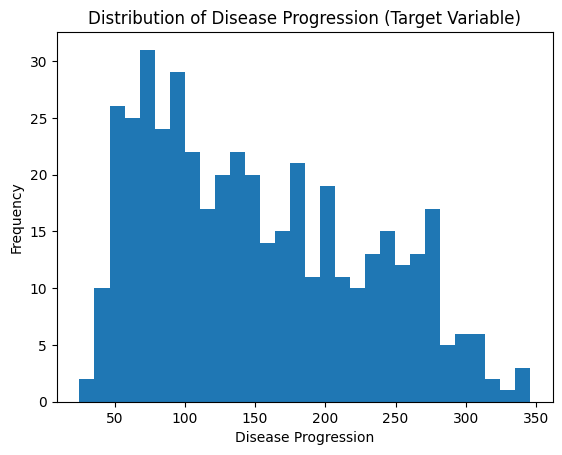

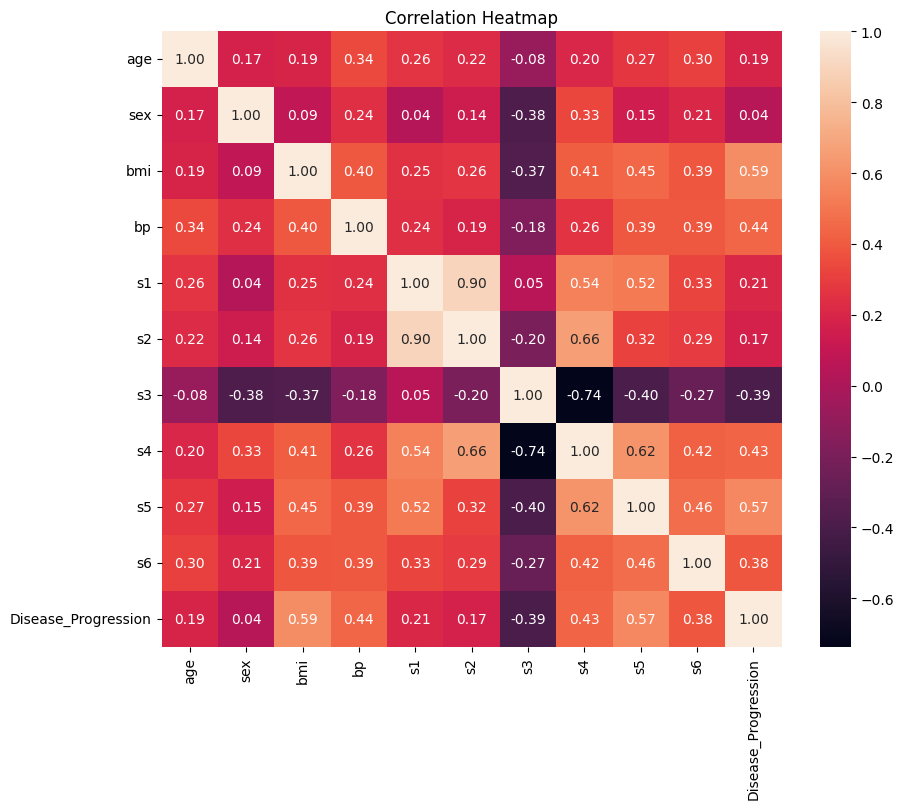

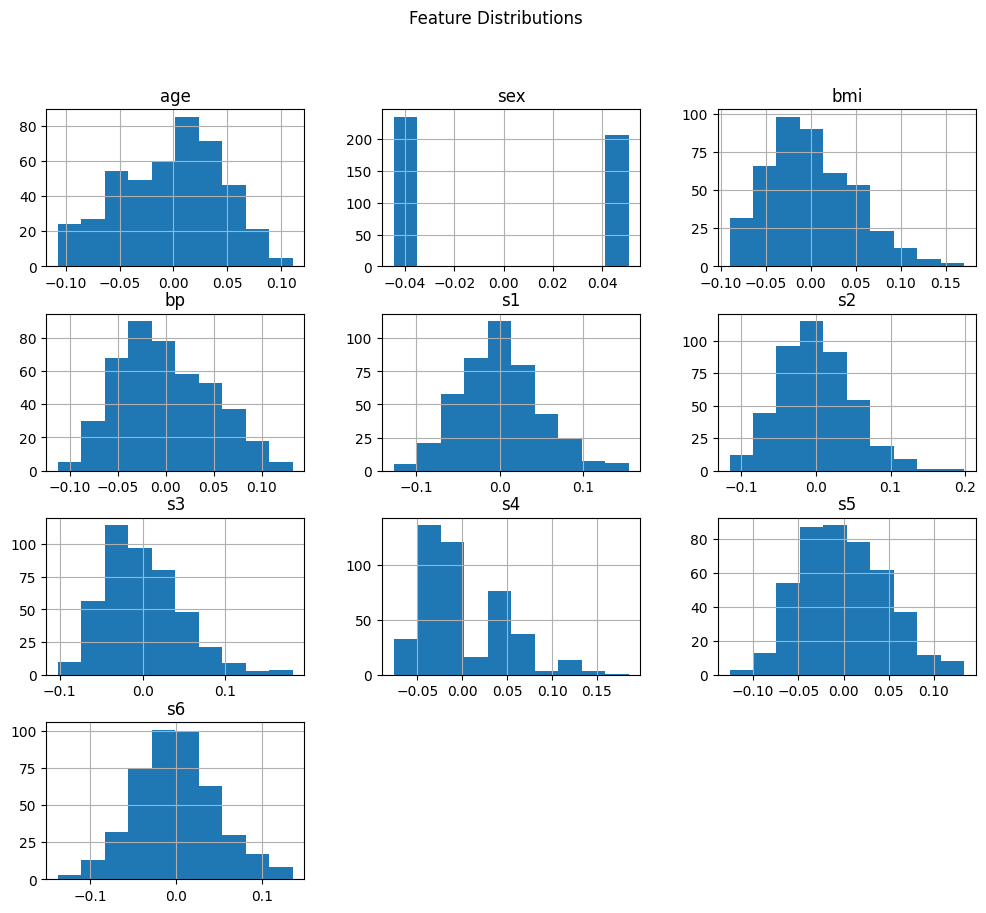

In [ ]:
# 3. Exploratory Data Analysis (EDA)
# 3.1 Basic Information
print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# 3.2 Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# 3.3 Target Variable Distribution
plt.figure()
plt.hist(y, bins=30)
plt.title("Distribution of Disease Progression (Target Variable)")
plt.xlabel("Disease Progression")
plt.ylabel("Frequency")
plt.show()

# 3.4 Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# 3.5 Feature Distribution Plots
df[X.columns].hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

In [ ]:
# 4. Feature Selection using Correlation Analysis
corr_matrix = X.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.90
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]

X_selected = X.drop(columns=to_drop)

print("\nRemoved Features:", to_drop)
print("Selected Feature Shape:", X_selected.shape)


Removed Features: []
Selected Feature Shape: (442, 10)


In [ ]:
# 5. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

In [ ]:
# 6. Model Selection
model = RandomForestRegressor(random_state=42)

In [ ]:
# 7. Cross Validation (K-Fold)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring='r2')

print("\nCross Validation R2 Scores:", cv_scores)
print("Mean R2 Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())


Cross Validation R2 Scores: [0.42687111 0.52943545 0.28398719 0.47681983 0.43225117]
Mean R2 Score: 0.4298729503243696
Standard Deviation: 0.08174842152200484


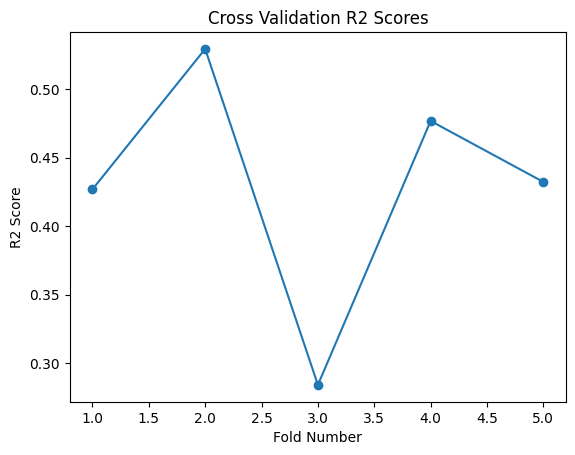

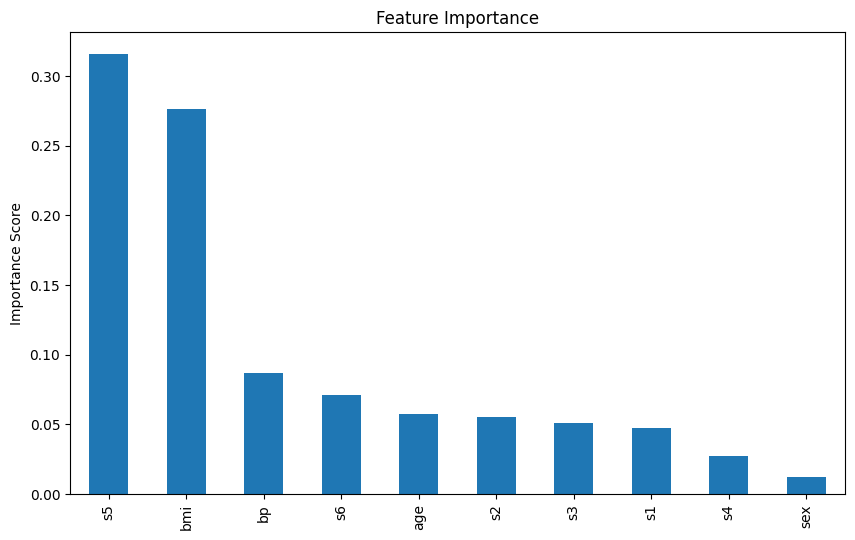

In [ ]:
# 8. Result Visualization

# 8.1 Cross Validation Score Plot
plt.figure()
plt.plot(range(1, 6), cv_scores, marker='o')
plt.title("Cross Validation R2 Scores")
plt.xlabel("Fold Number")
plt.ylabel("R2 Score")
plt.show()

# 8.2 Feature Importance Visualization
model.fit(X_scaled, y)
feature_importance = pd.Series(model.feature_importances_, index=X_selected.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.plot(kind='bar')
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()